In [2]:

import os
import random
import requests
import warnings
from datetime import datetime
from datetime import datetime, timedelta

import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools
from datetime import timedelta


# Suppress warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

# Time series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats 
# Scikit-learn utilities
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\twitter_complaint_data.csv')

In [4]:
df['time'] = pd.to_datetime(df['time'])

In [5]:
df

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...,...
1237,2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,27.0


In [8]:
final_df = df[['time', 'complaint_count']]

In [9]:
final_df

,time,complaint_count
0,2022-06-10,10.0
1,2022-06-11,12.0
2,2022-06-12,5.0
3,2022-06-13,15.0
4,2022-06-14,16.0
...,...,...
1237,2025-10-29,43.0
1238,2025-10-30,23.0
1239,2025-10-31,26.0
1240,2025-11-01,27.0


In [ ]:
# final_df.to_csv('complaint_count.csv', index=False)

In [4]:
df.set_index("time", inplace=True)

In [5]:
# Separate features (X) and target (y)
X = df.drop(columns=['complaint_count'])
y = df['complaint_count']
# Split data into train and test sets (80-20 split)
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print(f"Date range - Train: {df.index[0]} to {df.index[train_size-1]}")
print(f"Date range - Test: {df.index[train_size]} to {df.index[-1]}")

X_train shape: (993, 8)
X_test shape: (249, 8)
y_train shape: (993,)
y_test shape: (249,)
Training set size: 993
Test set size: 249
Date range - Train: 2022-06-10 00:00:00 to 2025-02-26 00:00:00
Date range - Test: 2025-02-27 00:00:00 to 2025-11-02 00:00:00


In [8]:
# 2) Helper metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    # avoid division by zero
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

In [37]:
# 3) Prepare data: scaling / sequence creation
# Parameters (tuneable)
LOOKBACK = 30         # use previous 30 time steps to predict next step
BATCH_SIZE = 32
EPOCHS = 100
VALIDATION_SPLIT = 0.1


In [38]:
# If X contains non-numeric columns, drop or encode them
def ensure_numeric_df(df_):
    df_n = df_.copy()
    for c in df_n.columns:
        if not np.issubdtype(df_n[c].dtype, np.number):
            try:
                df_n[c] = pd.to_numeric(df_n[c])
            except Exception:
                df_n.drop(columns=[c], inplace=True)
                print(f"Dropping non-numeric column {c}")
    return df_n

In [11]:
X = ensure_numeric_df(X)  # safe-guard (uses outer-scope X from the user's environment)

In [12]:
# Align indices (in case)
X_train = X_train.copy()
X_test = X_test.copy()
y_train = y_train.copy()
y_test = y_test.copy()


In [13]:
# Fit scalers on training data only
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [14]:
# Fit on numpy arrays
X_train_vals = X_train.values.astype(float)
X_test_vals = X_test.values.astype(float)
y_train_vals = y_train.values.reshape(-1, 1).astype(float)
y_test_vals = y_test.values.reshape(-1, 1).astype(float)

X_scaler.fit(X_train_vals)
y_scaler.fit(y_train_vals)

X_train_scaled = X_scaler.transform(X_train_vals)
X_test_scaled = X_scaler.transform(X_test_vals)
y_train_scaled = y_scaler.transform(y_train_vals).flatten()
y_test_scaled = y_scaler.transform(y_test_vals).flatten()

In [16]:
# Sequence creation for multivariate LSTM
def create_sequences(X, y, lookback=30):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:(i + lookback)])
        ys.append(y[i + lookback])
    return np.array(Xs), np.array(ys)

In [19]:
# Use last portion of training data for validation via Keras validation_split, but build sequences from full training
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
# For test sequences we must ensure alignment: use the entire dataset start for sequences on test partition
# Build test sequences from the combined X (train+test) starting at index train_size - LOOKBACK
# But here we have X_test scaled, so build sequences from X_test (will be shorter)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

In [20]:
print("Shapes after sequence creation:")
print(" X_train_seq:", X_train_seq.shape)
print(" X_test_seq :", X_test_seq.shape)
print(" y_train_seq:", y_train_seq.shape)
print(" y_test_seq :", y_test_seq.shape)

Shapes after sequence creation:
 X_train_seq: (963, 30, 8)
 X_test_seq : (219, 30, 8)
 y_train_seq: (963,)
 y_test_seq : (219,)


In [32]:
# 4) Model architecture (sensible, regularized)
n_features = X_train_seq.shape[2]
print("n_features:", n_features)

n_features: 8


In [33]:
def build_lstm_model(input_shape, units=64, lr=1e-3, dropout_rate=0.2, bidirectional=False):
    model = Sequential()
    if bidirectional:
        model.add(Bidirectional(LSTM(units, return_sequences=True), input_shape=input_shape))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(units//2, return_sequences=False)))
    else:
        model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(units//2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='linear'))
    optimizer = Adam(learning_rate=lr)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
    return model


In [35]:
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
model = build_lstm_model(input_shape, units=64, lr=1e-3, dropout_rate=0.2, bidirectional=False)
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,193 (125.75 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# 5) Callbacks
chkpt_path = "best_lstm_model.h5"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1, min_lr=1e-6),
    ModelCheckpoint(chkpt_path, monitor='val_loss', save_best_only=True, verbose=1)
]

In [39]:
# 6) Train
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=2,
    shuffle=True
)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.01063, saving model to best_lstm_model.h5


28/28 - 2s - 69ms/step - loss: 0.0092 - mae: 0.0647 - val_loss: 0.0106 - val_mae: 0.0852 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss improved from 0.01063 to 0.00755, saving model to best_lstm_model.h5


28/28 - 0s - 11ms/step - loss: 0.0084 - mae: 0.0607 - val_loss: 0.0076 - val_mae: 0.0674 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss did not improve from 0.00755
28/28 - 0s - 10ms/step - loss: 0.0083 - mae: 0.0608 - val_loss: 0.0076 - val_mae: 0.0680 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 0.00755 to 0.00754, saving model to best_lstm_model.h5


28/28 - 0s - 11ms/step - loss: 0.0079 - mae: 0.0588 - val_loss: 0.0075 - val_mae: 0.0671 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss improved from 0.00754 to 0.00738, saving model to best_lstm_model.h5


28/28 - 0s - 12ms/step - loss: 0.0076 - mae: 0.0573 - val_loss: 0.0074 - val_mae: 0.0664 - learning_rate: 1.0000e-03
Epoch 6/100

Epoch 6: val_loss did not improve from 0.00738
28/28 - 0s - 10ms/step - loss: 0.0077 - mae: 0.0579 - val_loss: 0.0088 - val_mae: 0.0749 - learning_rate: 1.0000e-03
Epoch 7/100

Epoch 7: val_loss improved from 0.00738 to 0.00685, saving model to best_lstm_model.h5


28/28 - 0s - 10ms/step - loss: 0.0077 - mae: 0.0569 - val_loss: 0.0069 - val_mae: 0.0630 - learning_rate: 1.0000e-03
Epoch 8/100

Epoch 8: val_loss did not improve from 0.00685
28/28 - 0s - 10ms/step - loss: 0.0075 - mae: 0.0584 - val_loss: 0.0093 - val_mae: 0.0773 - learning_rate: 1.0000e-03
Epoch 9/100

Epoch 9: val_loss did not improve from 0.00685
28/28 - 0s - 11ms/step - loss: 0.0075 - mae: 0.0569 - val_loss: 0.0093 - val_mae: 0.0774 - learning_rate: 1.0000e-03
Epoch 10/100

Epoch 10: val_loss did not improve from 0.00685
28/28 - 0s - 10ms/step - loss: 0.0076 - mae: 0.0572 - val_loss: 0.0077 - val_mae: 0.0680 - learning_rate: 1.0000e-03
Epoch 11/100

Epoch 11: val_loss did not improve from 0.00685
28/28 - 0s - 11ms/step - loss: 0.0074 - mae: 0.0559 - val_loss: 0.0077 - val_mae: 0.0682 - learning_rate: 1.0000e-03
Epoch 12/100

Epoch 12: val_loss did not improve from 0.00685
28/28 - 0s - 12ms/step - loss: 0.0073 - mae: 0.0559 - val_loss: 0.0074 - val_mae: 0.0669 - learning_rate: 1.0

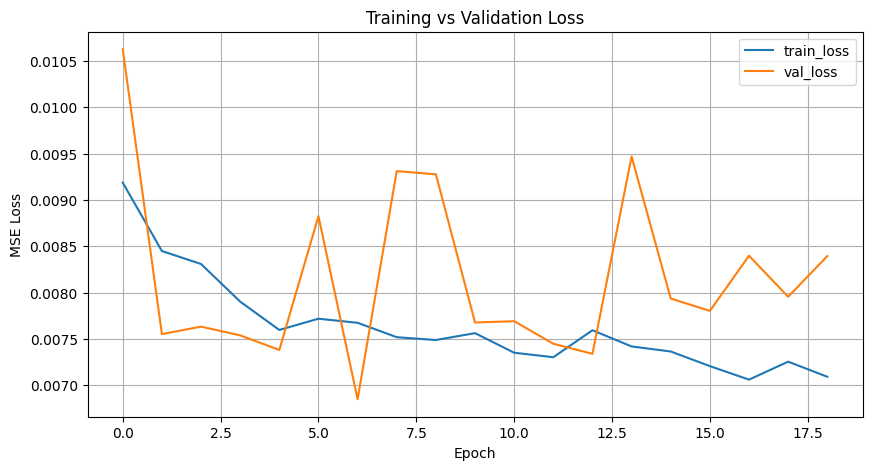

In [40]:
# 7) Plot training vs validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
# 8) Predict on test set and inverse-scale
y_pred_test_scaled = model.predict(X_test_seq).flatten()
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1,1)).flatten()
y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [42]:
# Align dates for plotting: build index for test predictions
# If original y_test has a datetime index, get the corresponding index for sequence predictions
try:
    # y_test is a pandas Series indexed by datetime. We need index positions corresponding to sequence targets.
    test_index = y_test.index[LOOKBACK:]  # sequence targets start at LOOKBACK offset within the test partition
except Exception:
    test_index = pd.RangeIndex(start=0, stop=len(y_pred_test))

pred_df = pd.DataFrame({
    'y_true': y_test_actual,
    'y_pred': y_pred_test
}, index=test_index)

In [43]:
# 9) Evaluation metrics
mae_v = mean_absolute_error(pred_df['y_true'], pred_df['y_pred'])
rmse_v = rmse(pred_df['y_true'], pred_df['y_pred'])
mape_v = mape(pred_df['y_true'], pred_df['y_pred'])

In [44]:
print("Test MAE:  ", mae_v)
print("Test RMSE: ", rmse_v)
print("Test MAPE: ", mape_v, "%")

Test MAE:   22.738007140486207
Test RMSE:  31.16554502492607
Test MAPE:  39.356690143416316 %


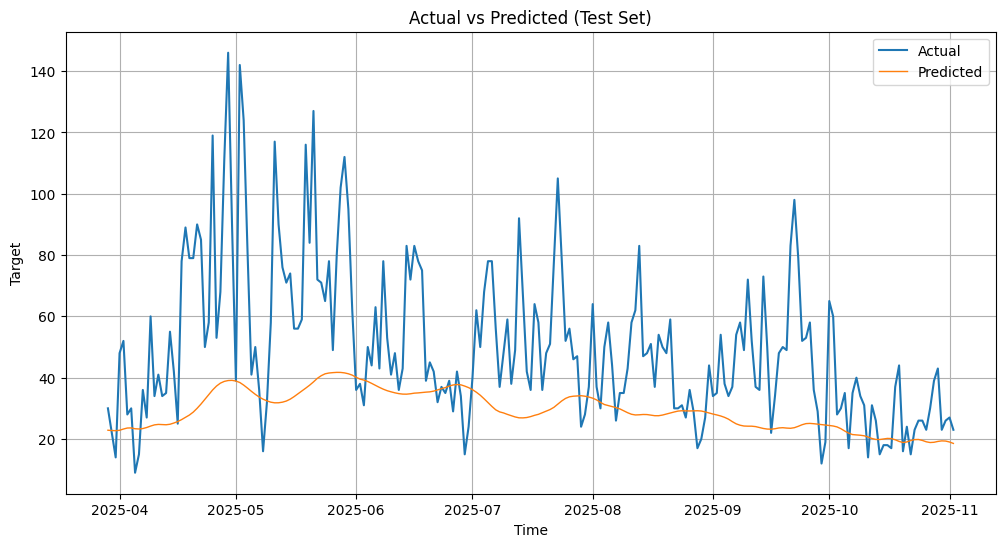

In [45]:
# 10) Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(pred_df['y_true'], label='Actual', linewidth=1.5)
plt.plot(pred_df['y_pred'], label='Predicted', linewidth=1)
plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()


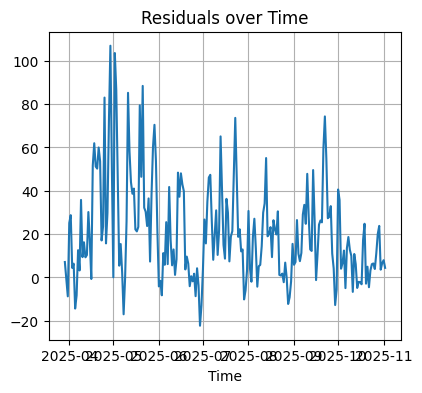

In [46]:
# 11) Residuals & error distribution
pred_df['residual'] = pred_df['y_true'] - pred_df['y_pred']

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(pred_df['residual'], label='Residuals')
plt.title('Residuals over Time')
plt.xlabel('Time')
plt.grid(True)


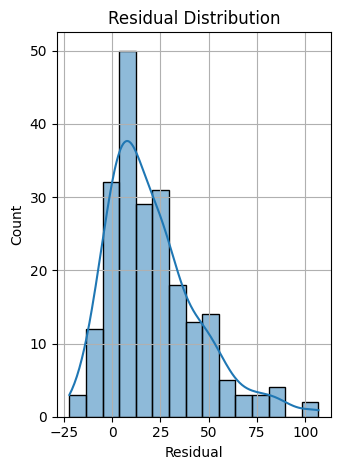

In [47]:
plt.subplot(1,2,2)
sns.histplot(pred_df['residual'], kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# 12) Residual diagnostics: mean ~ 0, homoscedasticity quick check
print("Residual mean:", pred_df['residual'].mean())
print("Residual std :", pred_df['residual'].std())

Residual mean: 20.76961835225423
Residual std : 23.28928553253987


In [49]:
def permutation_feature_importance(model, X_seq, y_true, feature_names, n_repeats=3):
    """
    X_seq: shape (n_samples, lookback, n_features)
    y_true: true targets (unscaled)
    Returns importance DataFrame sorted by mean delta_rmse.
    """
    base_pred_scaled = model.predict(X_seq).flatten()
    base_pred = y_scaler.inverse_transform(base_pred_scaled.reshape(-1,1)).flatten()
    base_rmse = rmse(y_true, base_pred)
    results = []
    X_seq_copy = X_seq.copy()
    for f_idx, fname in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_seq_copy.copy()
            # Permute entire column across samples and time steps independently
            # Flatten column (n_samples * lookback) then shuffle and reshape
            col = X_perm[:,:,f_idx].flatten()
            np.random.shuffle(col)
            X_perm[:,:,f_idx] = col.reshape(X_perm.shape[0], X_perm.shape[1])
            p_scaled = model.predict(X_perm).flatten()
            p = y_scaler.inverse_transform(p_scaled.reshape(-1,1)).flatten()
            rmse_perm = rmse(y_true, p)
            deltas.append(rmse_perm - base_rmse)
        results.append({
            'feature': fname,
            'delta_rmse_mean': np.mean(deltas),
            'delta_rmse_std': np.std(deltas)
        })
    imp_df = pd.DataFrame(results).sort_values('delta_rmse_mean', ascending=False).reset_index(drop=True)
    return imp_df, base_rmse

In [50]:
feature_names = list(X.columns)
imp_df, base_rmse = permutation_feature_importance(model, X_test_seq, y_test_actual, feature_names, n_repeats=3)
print("Base RMSE on test (for importance):", base_rmse)
print(imp_df.head(20))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Base RMSE on test (for importance): 31.16554502492607

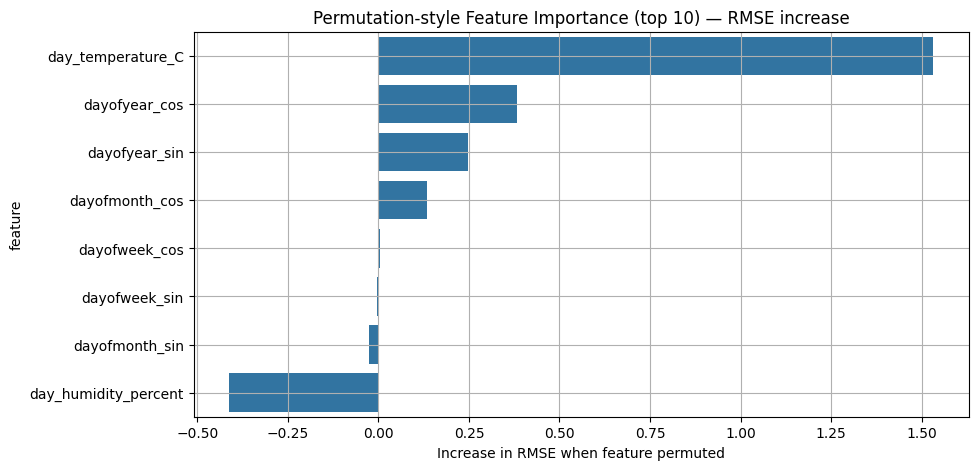

In [51]:
# Plot feature importance (top 10)
plt.figure(figsize=(10,5))
sns.barplot(data=imp_df.head(10), x='delta_rmse_mean', y='feature')
plt.title('Permutation-style Feature Importance (top 10) — RMSE increase')
plt.xlabel('Increase in RMSE when feature permuted')
plt.grid(True)
plt.show()

In [52]:
# 14) Forecast next 30 days
# Strategy:
# - If user-provided future exogenous features are available (e.g., X_future), use them.
# - Otherwise, create future time-based features from df.index if present and use last observed values for other features.
# - Iterative forecast: use last LOOKBACK rows (scaled) and append predicted values, shifting window forward.

In [55]:
HORIZON = 30


In [56]:
def prepare_future_features(df_reference, X_scaler, horizon, lookback):
    """
    Attempt to create future features for forecasting if not provided.
    - If df_reference (original df) has a DatetimeIndex, will create a future index and basic temporal features.
    - For features that cannot be generated, use last observed value per feature.
    Returns: X_future_df (horizon x n_features) aligned to the columns used during training.
    """
    col_names = X.columns.tolist()
    # build future index
    if isinstance(df_reference.index, pd.DatetimeIndex):
        last_ts = df_reference.index[-1]
        # assume daily frequency if not identifiable
        try:
            inferred = pd.date_range(start=last_ts + (df_reference.index[1] - df_reference.index[0]), periods=horizon, freq=None)
        except Exception:
            inferred = pd.date_range(start=last_ts + pd.Timedelta(days=1), periods=horizon, freq='D')
        future_idx = inferred
    else:
        future_idx = pd.RangeIndex(start=len(df_reference), stop=len(df_reference) + horizon)

    # create df with placeholders
    X_future = pd.DataFrame(index=future_idx, columns=col_names, dtype=float)

    # fill time features if present in names (heuristic)
    for c in col_names:
        if 'hour' in c.lower():
            X_future[c] = [ts.hour if hasattr(ts, 'hour') else 0 for ts in future_idx]
        elif 'dayofweek' in c.lower() or 'weekday' in c.lower():
            X_future[c] = [ts.dayofweek if hasattr(ts, 'dayofweek') else 0 for ts in future_idx]
        elif 'dayofmonth' in c.lower():
            X_future[c] = [ts.day if hasattr(ts, 'day') else 1 for ts in future_idx]
        elif 'month' in c.lower():
            X_future[c] = [ts.month if hasattr(ts, 'month') else 1 for ts in future_idx]
        else:
            # fallback: use last observed value of that column from df_reference
            if c in df_reference.columns:
                X_future[c] = df_reference[c].iloc[-1]
            else:
                X_future[c] = 0.0

    return X_future


Constructed X_future heuristically (time features + last-observed values).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━

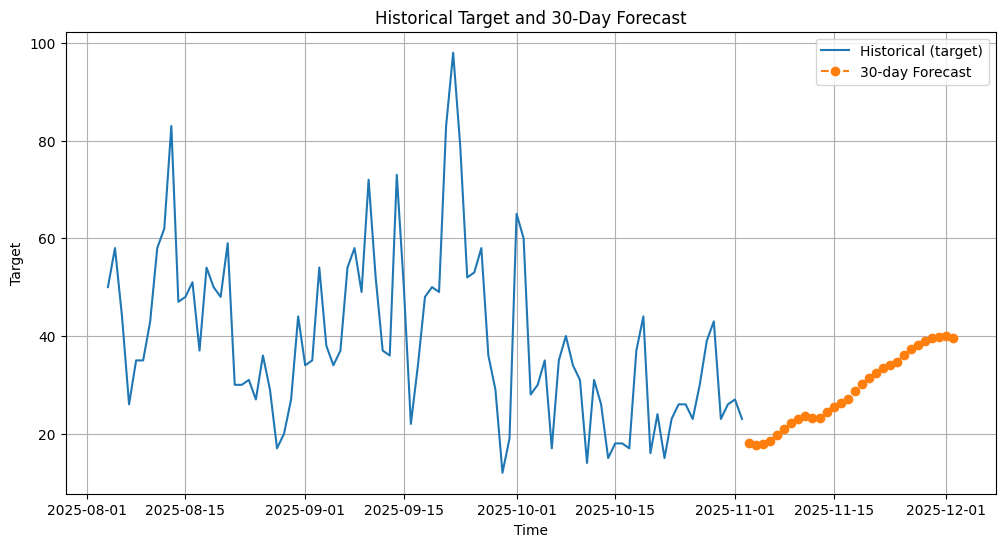

In [57]:
# if user has X_future available in environment, prefer it
X_future_provided = globals().get('X_future', None)
if X_future_provided is not None:
    X_future_df = X_future_provided.copy()
    print("Using user-provided X_future for horizon forecasting.")
else:
    X_future_df = prepare_future_features(df, X_scaler, HORIZON, LOOKBACK)
    print("Constructed X_future heuristically (time features + last-observed values).")

# scale X_future
X_future_scaled = X_scaler.transform(X_future_df.values.astype(float))

# Start iterative forecasting using most recent LOOKBACK scaler inputs.
# We will use the last LOOKBACK rows from the *full* dataset (train+test) for features
# Build a rolling buffer: last_window shape (lookback, n_features)
# Prefer actual last observed X (from original X). If index alignment issues, use X_test tail or X overall last.
try:
    full_X_scaled = np.vstack([X_scaler.transform(X.values.astype(float))])  # scaled whole X
    last_window = full_X_scaled[-LOOKBACK:]  # last lookback rows
except Exception:
    # fallback: use the last LOOKBACK rows from X_test_scaled if available
    last_window = X_test_scaled[-LOOKBACK:]

assert last_window.shape == (LOOKBACK, n_features)

forecast_scaled = []
window = last_window.copy()

for step in range(HORIZON):
    # model expects shape (1, lookback, n_features)
    input_arr = window.reshape(1, LOOKBACK, n_features)
    pred_scaled = model.predict(input_arr).flatten()[0]  # scaled target
    forecast_scaled.append(pred_scaled)
    # prepare next window: shift by one and append features for next step
    # we will replace feature columns that correspond to target with predicted if target is among features;
    # otherwise keep other scaled X_future row as next feature row.
    if step < X_future_scaled.shape[0]:
        next_x_row = X_future_scaled[step]
    else:
        # fallback: reuse last X row
        next_x_row = window[-1]
    # If your features include the target (lagged target column name e.g. 'complaint_count_lag1'), ensure to update them here.
    # For generic handling, we push the new next_x_row into the window
    window = np.vstack([window[1:], next_x_row])

# invert scale for forecasts
forecast_scaled_arr = np.array(forecast_scaled).reshape(-1,1)
forecast_values = y_scaler.inverse_transform(forecast_scaled_arr).flatten()

# build forecast index (matching future index)
try:
    forecast_index = X_future_df.index[:HORIZON]
except Exception:
    forecast_index = pd.RangeIndex(start=0, stop=HORIZON)

forecast_df = pd.DataFrame({'forecast': forecast_values}, index=forecast_index)
print("30-day forecast (head):")
print(forecast_df.head())

# 15) Visualize forecast appended to historical
# Choose a slice of recent history + forecast for context
try:
    recent_history = y.loc[y.index >= (df.index[-1] - pd.Timedelta(days=90))]
except Exception:
    recent_history = y.tail(90)

plt.figure(figsize=(12,6))
plt.plot(recent_history.index, recent_history.values, label='Historical (target)')
plt.plot(forecast_df.index, forecast_df['forecast'].values, label='30-day Forecast', linestyle='--', marker='o')
plt.title('Historical Target and 30-Day Forecast')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# 16) Comparison (if actual future becomes available)
# Provide a function that compares predictions vs actuals once actual future values are available
def compare_predictions(actual_series, predicted_df):
    # actual_series: pandas Series indexed by same index as predicted_df
    # predicted_df: DataFrame with 'forecast' column
    common_idx = actual_series.index.intersection(predicted_df.index)
    if len(common_idx) == 0:
        print("No overlapping index between actuals and predictions.")
        return None
    actual = actual_series.loc[common_idx].values
    pred = predicted_df.loc[common_idx, 'forecast'].values
    return {
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': rmse(actual, pred),
        'MAPE': mape(actual, pred)
    }

# 18) Summary report (console)
print("\n--- Summary Report ---")
print(f"Sequences -> lookback: {LOOKBACK}, n_features: {n_features}")
print(f"Train sequences: {X_train_seq.shape[0]}, Test sequences: {X_test_seq.shape[0]}")
print(f"Test MAE: {mae_v:.4f}, Test RMSE: {rmse_v:.4f}, Test MAPE: {mape_v:.2f}%")
print("Permutation importance (top 8):")
print(imp_df.head(8).to_string(index=False))
print("\n30-day forecast (summary):")
print(forecast_df['forecast'].describe())



--- Summary Report ---
Sequences -> lookback: 30, n_features: 8
Train sequences: 963, Test sequences: 219
Test MAE: 22.7380, Test RMSE: 31.1655, Test MAPE: 39.36%
Permutation importance (top 8):
             feature  delta_rmse_mean  delta_rmse_std
   day_temperature_C         1.532854        0.015633
       dayofyear_cos         0.381660        0.060975
       dayofyear_sin         0.248409        0.027252
      dayofmonth_cos         0.135469        0.015405
       dayofweek_cos         0.003088        0.023215
       dayofweek_sin        -0.002636        0.025463
      dayofmonth_sin        -0.025715        0.046877
day_humidity_percent        -0.413119        0.005975

30-day forecast (summary):
count    30.000000
mean     28.854998
std       7.703047
min      17.594538
25%      23.120602
50%      27.876516
75%      35.820487
max      40.056351
Name: forecast, dtype: float64
